##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import random
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
import os

dataset_directory = r"C:\Users\Dhoha\Downloads\UCF11_updated_mpg\UCF11_updated_mpg"

print(os.path.exists(dataset_directory))
print(os.listdir(dataset_directory)[:10])

True
['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking']


In [3]:
dataset_directory = r"C:\Users\Dhoha\Downloads\UCF11_updated_mpg\UCF11_updated_mpg"

In [4]:
classes_list = ["basketball", "biking", "tennis_swing"]

In [5]:
def frames_extraction(video_path):

    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    while True:
        success, frame = video_reader.read()
        if not success:
            break

        resized_frame = cv2.resize(frame, (64, 64))
        normalized_frame = resized_frame / 255.0

        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

In [6]:
def create_dataset():

    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):

        class_path = os.path.join(dataset_directory, class_name)

        for group in os.listdir(class_path):
            group_path = os.path.join(class_path, group)

            if os.path.isdir(group_path):

                for video in os.listdir(group_path):
                    video_path = os.path.join(group_path, video)

                    frames = frames_extraction(video_path)

                    if len(frames) > 0:
                        selected_frames = random.sample(frames, min(30, len(frames)))

                        features.extend(selected_frames)
                        labels.extend([class_index] * len(selected_frames))

    features = np.array(features)
    labels = np.array(labels)

    return features, labels

In [7]:
features, labels = create_dataset()
labels = to_categorical(labels)

In [8]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    shuffle=True,
    random_state=23
)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

def create_model():

    model = Sequential()

    model.add(Conv2D(64, (3,3), activation='relu', input_shape=(64, 64, 3)))
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(len(classes_list), activation='softmax'))

    return model

model = create_model()
model.summary()

c:\Users\Dhoha\anaconda3\envs\cv_lab\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

In [10]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    features_train,
    labels_train,
    epochs=10,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 67s 60ms/step - accuracy: 0.7332 - loss: 0.6234 - val_accuracy: 0.4533 - val_loss: 1.9324
Epoch 2/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 115s 107ms/step - accuracy: 0.8645 - loss: 0.3423 - val_accuracy: 0.8993 - val_loss: 0.3318
Epoch 3/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 150s 114ms/step - accuracy: 0.9213 - loss: 0.2243 - val_accuracy: 0.8050 - val_loss: 0.8069
Epoch 4/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 132s 122ms/step - accuracy: 0.9301 - loss: 0.1961 - val_accuracy: 0.8720 - val_loss: 0.4043
Epoch 5/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 156s 145ms/step - accuracy: 0.9410 - loss: 0.1669 - val_accuracy: 0.9432 - val_loss: 0.1707
Epoch 6/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 157s 145ms/step - accuracy: 0.9493 - loss: 0.1381 - val_accuracy: 0.8276 - val_loss: 0.5396
Epoch 7/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 158s 146ms/step - accuracy: 0.9523 - loss: 0.1328 - val_accuracy: 0.9635 - val_loss: 0.1113
Epoch 8/10
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 125s 75ms/step - accur

In [12]:
student_name = "Dhoha"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

Model saved as Dhoha_ucf11_model.h5


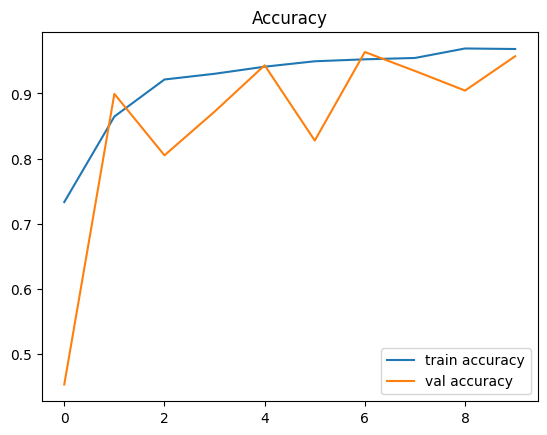

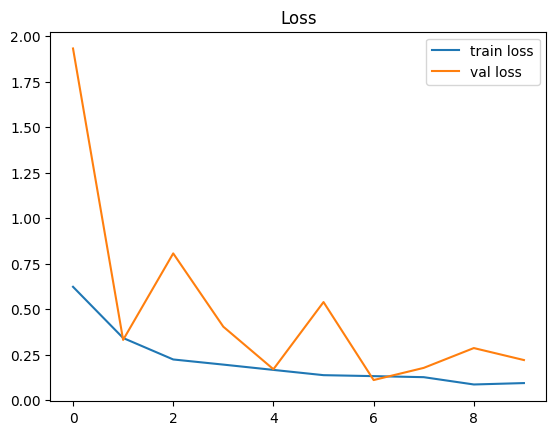

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [18]:
predict_video(r"C:\Users\Dhoha\Downloads\UCF11_updated_mpg\basketball\...\video.avi")

C:\Users\Dhoha\AppData\Local\Temp\ipykernel_2944\1119415786.py:20: RuntimeWarning: Mean of empty slice
  avg = predictions.mean(axis=0)


'basketball'

In [24]:
import os
import random

def get_sample_video(class_name):
    class_path = os.path.join(dataset_directory, class_name)

    for folder in os.listdir(class_path):

        folder_path = os.path.join(class_path, folder)

        # SKIP annotation folders
        if "annotation" in folder.lower():
            continue

        if os.path.isdir(folder_path):
            videos = os.listdir(folder_path)

            # filter only video files
            videos = [v for v in videos if v.endswith(('.avi', '.mpg', '.mp4'))]

            if len(videos) == 0:
                continue

            video = random.choice(videos)
            return os.path.join(folder_path, video)

In [25]:
basketball_video = get_sample_video("basketball")
biking_video = get_sample_video("biking")
tennis_video = get_sample_video("tennis_swing")

print(basketball_video)
print(biking_video)
print(tennis_video)

C:\Users\Dhoha\Downloads\UCF11_updated_mpg\UCF11_updated_mpg\basketball\v_shooting_01\v_shooting_01_03.mpg
C:\Users\Dhoha\Downloads\UCF11_updated_mpg\UCF11_updated_mpg\biking\v_biking_01\v_biking_01_01.mpg
C:\Users\Dhoha\Downloads\UCF11_updated_mpg\UCF11_updated_mpg\tennis_swing\v_tennis_01\v_tennis_01_03.mpg


In [26]:
print("Basketball:", predict_video(basketball_video))
print("Biking:", predict_video(biking_video))
print("Tennis:", predict_video(tennis_video))

Basketball: basketball
Biking: biking
Tennis: tennis_swing


In [27]:
student_name = "Dhoha"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

Model saved as Dhoha_ucf11_model.h5
